In [1]:
from pathlib import Path


def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit(
        "ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run "
        "jupyter lab)"
    )


DATA = data_dir()


**Dataset ที่ใช้ในโมดูลนี้ (โปรดอ่านก่อนใช้งาน):**

- *SECOM* — McCann, M. & Johnston, A. (2008). *SECOM* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C54305 (CC BY 4.0)
- *Combined Cycle Power Plant* — Tüfekci, P. & Kaya, H. (2014). *Combined Cycle Power Plant* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5002N (CC BY 4.0)

ไฟล์: `datasets/secom.zip`, `datasets/ccpp_power_plant.csv`

---

**เวลาที่คาดหวังสำหรับแบบฝึกหัดนี้:** ~45 นาที (ทำในห้องช่วง lab — เฉลยเปิดเผยหลังจบช่วง)


# Exercise — Module 5: Evaluation

ใช้ความรู้จาก `book.ipynb`: confusion matrix, precision/recall/F1, threshold sweep, ROC-AUC vs PR-AUC, cross-validation, random-vs-time split, และ regression metrics ทั้งหมดใช้ `random_state=42` ให้รัน cell ด้านล่างเพื่อโหลดข้อมูลก่อนเริ่ม

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)

---- SECOM (classification part) ----

---- CCPP (regression part) ----


In [2]:
from sklearn.preprocessing import StandardScaler  # noqa: E402
from sklearn.pipeline import make_pipeline  # noqa: E402
from sklearn.model_selection import (  # noqa: E402,F401
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.metrics import (  # noqa: E402,F401
    accuracy_score,
    average_precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.linear_model import (  # noqa: E402,F401
    LinearRegression,
    LogisticRegression,
    Ridge,
)
from sklearn.impute import SimpleImputer  # noqa: E402
from sklearn.ensemble import (  # noqa: E402,F401
    RandomForestClassifier,
    RandomForestRegressor,
)
import polars as pl  # noqa: E402
import numpy as np  # noqa: E402
import io  # noqa: E402
import zipfile  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

with zipfile.ZipFile(DATA / "secom.zip") as z:
    feats = pl.read_csv(
        io.BytesIO(z.read("secom.data")),
        separator=" ",
        has_header=False,
        new_columns=[f"feature_{i}" for i in range(1, 591)],
        schema_overrides={f"feature_{i}": pl.Float64 for i in range(1, 591)},
    )
    lab = pl.read_csv(
        io.BytesIO(z.read("secom_labels.data")),
        separator=" ",
        quote_char='"',
        has_header=False,
        new_columns=["label", "timestamp"],
        schema_overrides={"label": pl.Int64, "timestamp": pl.Utf8},
    )
y_secom = (lab["label"] == 1).to_numpy().astype(int)  # 1 = FAIL
X_secom = feats.to_numpy()
cut = int(len(y_secom) * 0.8)
Xtr_t, Xte_t = X_secom[:cut], X_secom[cut:]  # time-based split
ytr_t, yte_t = y_secom[:cut], y_secom[cut:]

ccpp = pl.read_csv(DATA / "ccpp_power_plant.csv")
Xc = ccpp.select("AT", "V", "AP", "RH").to_numpy()
yc = ccpp["PE"].to_numpy()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=42
)

print(f"SECOM {X_secom.shape}, fails {y_secom.sum()} | CCPP {ccpp.shape}")

SECOM (1567, 590), fails 104 | CCPP (9568, 5)


## ข้อ A1 — เขียน `evaluate()` : ไม้บรรทัดมาตรฐานของ QC lab

เขียนฟังก์ชัน `evaluate(model, X_train, y_train, X_test, y_test)` ที่ fit โมเดล (ภายใน pipeline: `SimpleImputer(median)` → `StandardScaler()` → model) แล้วคืน `dict` ของ metric 6 ตัวบน test set: `accuracy`, `precision`, `recall`, `f1`, `roc_auc`, `pr_auc` จากนั้นรันกับ `LogisticRegression(max_iter=2000, random_state=42)` บน time split ที่เตรียมไว้ แล้วตอบ: **accuracy กับ recall ตัวไหนบอกคุณภาพของ gauge ได้ตรงกว่า และเพราะอะไร** (ตอบใน markdown)

TODO


In [3]:
def evaluate(model, X_train, y_train, X_test, y_test):
    """Fit (impute -> scale -> model) and return 6 standard metrics on the "
    "test set."""
    pipe = ...  # noqa: F841
    ...
    proba = ...  # noqa: F841
    pred = ...  # noqa: F841
    return {
        "accuracy": ...,
        "precision": ...,
        "recall": ...,
        "f1": ...,
        "roc_auc": ...,
        "pr_auc": ...,
    }


metrics_log = evaluate(
    LogisticRegression(max_iter=2000, random_state=42),
    Xtr_t,
    ytr_t,
    Xte_t,
    yte_t,
)
for k, v in metrics_log.items():
    print(f"{k:>10s} = {v:.3f}")

TypeError: unsupported format string passed to ellipsis.__format__

**คำใบ้:** ใช้ `make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), model)` — อย่าลืมว่า SECOM มี NaN ต้อง impute ก่อนเสมอ | `precision_score(..., zero_division=0)` กัน warning ตอนโมเดลไม่ทำนาย FAIL เลย | `proba = pipe.predict_proba(X_test)[:, 1]` สำหรับ `roc_auc_score` และ `average_precision_score` | ตอบคำถามท้ายข้อด้วยการเทียบ "โมเดลเกเรที่เดา PASS ทุกชิ้น" ว่าได้ accuracy เท่าไร

## ข้อ A2 — เทียบ Logistic vs RandomForest ด้วย stratified 5-fold CV

ใช้ `evaluate` เป็นแนวคิด (แต่คราวนี้เราต้องการค่าเฉลี่ยที่ repeatable): วัด `roc_auc` และ `average_precision` ของ `LogisticRegression(max_iter=2000, random_state=42)` กับ `RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)` ด้วย `cross_validate` + `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` บน SECOM **ทั้งชุด** แล้วพิมพ์ mean ± std ต่อโมเดล ตอบ: **ความต่างของสองโมเดลใหญ่พอที่จะสรุปได้ไหม เทียบกับ spread (std) ของ folds** (แนวคิด repeatability จากหัวข้อ 6)

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
candidates = {
    "Logistic": ...,
    "RandomForest": ...,
}
for name, model in candidates.items():
    res = ...
    for s in ["roc_auc", "average_precision"]:
        v = res[f"test_{s}"]
        print(f"{name:12s} {s:<18s} {v.mean():.3f} ± {v.std():.3f}")


TypeError: 'ellipsis' object is not subscriptable

**คำใบ้:** `cross_validate(pipe, X_secom, y_secom, cv=cv, scoring=["roc_auc", "average_precision"])` — สร้าง pipeline (impute→scale→model) ต่อโมเดลก่อนส่งเข้า `cross_validate` | RandomForest ไม่ต้องกลัว scale แต่ใส่ scaler รวมไว้ก็ไม่เสียหาย และ imputer จำเป็น (RF ของ sklearn ไม่รับ NaN)

## ข้อ A3 — เลือก threshold จากต้นทุนจริง: false accept แพงกว่า false reject 50 เท่า

สมมติ QC lab ให้ต้นทุนดังนี้: **false accept (ปล่อยของเสียผ่าน) มีต้นทุน 50 หน่วย** (field failure / recall จากลูกค้า) ส่วน **false reject (ตัดของดีทิ้ง) มีต้นทุน 1 หน่วย** (ค่า re-inspection) — เทรน `LogisticRegression(max_iter=2000, random_state=42)` บน time split (ใช้ pipeline แบบข้อ A1) กวาด threshold จาก 0.05 ถึง 0.90 (ก้าว 0.05) คำนวณ **expected cost = 50 × FN + 1 × FP** ที่แต่ละ threshold พลอต cost กับ threshold แล้วตอบ: **threshold ที่ต้นทุนต่ำสุดคือเท่าไร ต่างจาก default 0.5 อย่างไร และสมเหตุสมผลไหม**

TODO: plot cost vs threshold, mark the minimum and the default 0.5


In [5]:
clf = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42),
).fit(Xtr_t, ytr_t)
y_proba = clf.predict_proba(Xte_t)[:, 1]

thresholds = np.round(np.arange(0.05, 0.91, 0.05), 2)
costs = []
for t in thresholds:
    pred_t = ...
    tn, fp, fn, tp = ...
    costs.append(...)

best_t = ...
print(f"best threshold = {best_t:.2f} at cost = {min(costs):.0f}")

fig, ax = plt.subplots(figsize=(7, 3.6))
...
plt.show()

TypeError: cannot unpack non-iterable ellipsis object

**คำใบ้:** ดึง confusion matrix ด้วย `confusion_matrix(yte_t, pred_t).ravel()` (ลำดับคือ TN, FP, FN, TP — FN คือ false accept!) | `costs.append(50 * fn + 1 * fp)` | จุดต่ำสุด: `best_t = thresholds[int(np.argmin(costs))]` | พลอตด้วย `ax.plot(thresholds, costs, ...)` + `ax.scatter([best_t], [min(costs)], color="#e76f51")` + `ax.axvline(0.5, ...)`

## ข้อ B1 — Regression metrics สองโมเดลบน CCPP

เทียบ `LinearRegression` กับ `RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)` (ครอบด้วย pipeline `SimpleImputer(median)` → `StandardScaler()` → model ได้ แม้ CCPP ไม่มี NaN) บน split ที่เตรียมไว้ (`Xc_tr/yc_tr`, `Xc_te/yc_te`) คำนวณ **R², RMSE, MAE** ของทั้งสองโมเดล แล้วตอบใน markdown: **metric ตัวใดเหมาะกับเล่าเรื่องเมโทรโลยีที่สุด (เช่น "ทำนายกำลังไฟฟ้าได้ภายในกี่ MW") และเพราะอะไร**

In [6]:
reg_candidates = {
    "Linear": ...,
    "RandomForest": ...,
}
reg_results = {}
for name, model in reg_candidates.items():
    pipe = ...
    ...
    pred = ...
    reg_results[name] = {
        "R2": ...,
        "RMSE": ...,
        "MAE": ...,
    }
    print(
        f"{name:12s} R2={reg_results[name]['R2']:.4f}  RMSE={
            reg_results[name]['RMSE']:.2f} MW  MAE={
            reg_results[name]['MAE']:.2f} MW"
    )


TypeError: unsupported format string passed to ellipsis.__format__

**คำใบ้:** `RMSE = np.sqrt(mean_squared_error(yc_te, pred))` | ใน sklearn 1.9 ใช้ `mean_squared_error(..., squared=False)` ไม่ได้แล้ว (ถูกถอดออก) — ใช้ `np.sqrt` เอง | คิดว่า metric ตัวไหนอยู่ใน **หน่วยเดียวกับ y (MW)** และโดน outlier หนัก/เบาแค่ไหน

## ข้อ B2 — Residual plot + relative error ของโมเดลที่ดีกว่า

เลือกโมเดลที่ชนะในข้อ B1 แล้ว: (1) พลอต **residual vs predicted** (พร้อมเส้นศูนย์สีแดง) แล้วพิจารณาว่ามี **bias** (เอียงเป็นระบบ) หรือแค่ **spread** (กระจายรอบศูนย์) (2) คำนวณ **MAPE-style relative error** = mean(|residual / actual|) × 100 แล้วตอบใน markdown: **residual กระจายแบบไหน และ relative error ราวกี่ % — ตัวเลขนี้พอจะสื่อสารกับผู้ใช้งานเครื่องจักรได้ไหม**

TODO: ใช้โมเดลที่ชนะจากข้อ B1 แล้วทำ residual plot + MAPE-style relative error

TODO: scatter pred_best vs resid + เส้นศูนย์


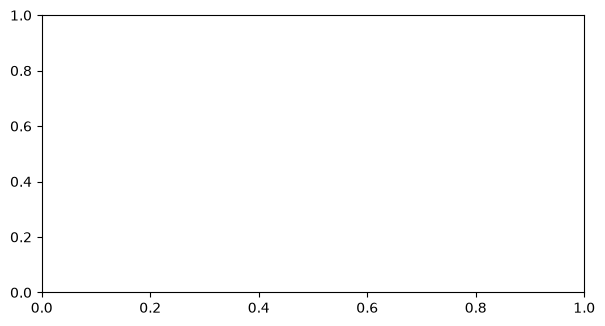

TypeError: unsupported format string passed to ellipsis.__format__

In [7]:
best_reg = ...
pred_best = ...
resid = ...

fig, ax = plt.subplots(figsize=(7, 3.6))
...
plt.show()

mape = ...
print(f"MAPE-style relative error = {mape:.2f}%")
print(
    f"bias (mean residual) = {resid.mean():+.3f} MW | spread (std residual) = {
        resid.std():.2f} MW"
)

**คำใบ้:** `resid = yc_te - pred_best` | `ax.scatter(pred_best, resid, s=12, color="#264653")` + `ax.axhline(0, color="#e76f51")` | `mape = float(np.mean(np.abs(resid / yc_te)) * 100)`

## ข้อ B3 — โจทย์คิด (ตอบใน markdown)

1. ทีมขายอยากประกาศว่า "โมเดลตรวจ SECOM แม่นยำ 93%" — คุณจะอธิบายอย่างไรว่าทำไมตัวเลขนี้ไม่พอสำหรับการตัดสินใจใช้ gauge จริง และจะเสนอรายงานชุด metric ใดแทน (ระบุชื่อ metric พร้อมเหตุผลสั้น ๆ)
2. โมเดล RF ได้ ROC-AUC จาก random split สูงกว่า time split อย่างชัดเจน ถ้านโยบายของ lab คือ "รายงานคะแนนที่ดีที่สุด" ควรทำอย่างไรจึงจะซื่อสัตย์ต่อการใช้งานจริง

**คำตอบข้อ B3:** *(เขียนคำตอบที่นี่)*